<a href="https://colab.research.google.com/github/AfraazUlHaque/data-analytics/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [49]:
df = pd.read_csv("employee_dataset_2.csv")
df.tail()


,Employee_ID,Age,Gender,Department,Job_Role,Years_of_Experience,Monthly_Salary,Performance_Rating,Work_Hours_per_Week,Overtime_Hours_per_Week,Attrition_Status
197,196,45,Other,Sales,Manager,NaN,106497.0,4.0,45.0,12.0,No
198,197,29,Male,HR,Analyst,19.0,69879.0,4.0,47.0,14.0,No
199,198,45,Female,Marketing,Manager,33.0,79871.0,1.0,NaN,10.0,Yes
200,199,37,Male,Sales,Developer,25.0,109388.0,4.0,58.0,10.0,No
201,200,47,Male,IT,NaN,4.0,118646.0,1.0,51.0,11.0,No


In [50]:
len(df)

202

In [51]:
df = df[
    (df['Age'] - df['Years_of_Experience']) >= 18
]

len(df)

123

In [52]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Job_Role,11
Years_of_Experience,0
Monthly_Salary,16
Performance_Rating,2
Work_Hours_per_Week,13
Overtime_Hours_per_Week,2


In [54]:
df = df.dropna(subset = ['Monthly_Salary'])
len(df)

107

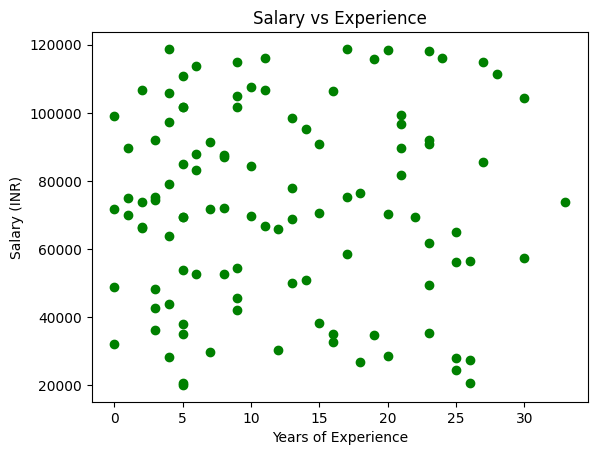

In [55]:
x = df[['Years_of_Experience']]
y = df['Monthly_Salary']
plt.scatter(x, y, color="green")
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (INR)")
plt.show()

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state =22)

In [58]:
from sklearn.linear_model import LinearRegression


model= LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [59]:
print("Coefficient : ", model.coef_[0])
print("Intercept : ", model.intercept_)

Coefficient :  -1.2343036900567474
Intercept :  74663.55188401588


In [60]:
y_pred = model.predict(X_test)
print(y_pred)

[74631.45998807 74641.33441759 74654.91175819 74626.52277331
 74631.45998807 74657.38036557 74656.14606188 74635.16289914
 74658.61466926 74654.91175819 74662.31758033 74663.55188402
 74654.91175819 74638.86581021 74657.38036557 74647.50593605
 74630.22568438 74657.38036557 74643.80302497 74657.38036557
 74647.50593605 74658.61466926]


In [61]:
from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score : ", r2)


R2 Score :  -0.20125567123484078


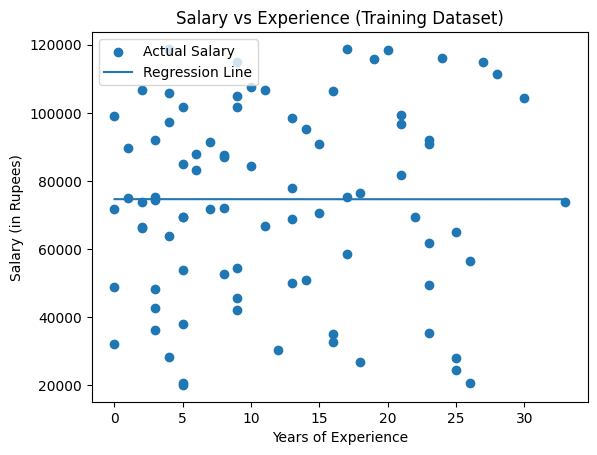

In [66]:
import matplotlib.pyplot as plt

# Actual training data
plt.scatter(X_train, y_train, label="Actual Salary")

# Regression line
plt.plot(
    X_train.sort_values("Years_of_Experience"),
    model.predict(X_train.sort_values("Years_of_Experience")),
    label="Regression Line"
)

plt.title("Salary vs Experience (Training Dataset)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (in Rupees)")
plt.legend()
plt.show()

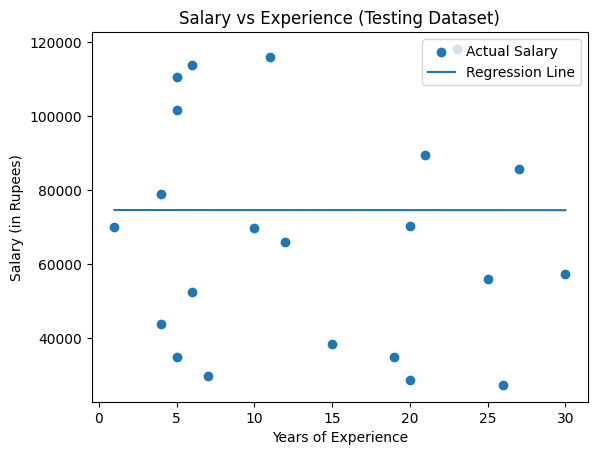

In [65]:
plt.scatter(X_test, y_test, label="Actual Salary")

plt.plot(
    X_test.sort_values("Years_of_Experience"),
    model.predict(X_test.sort_values("Years_of_Experience")),
    label="Regression Line"
)

plt.title("Salary vs Experience (Testing Dataset)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (in Rupees)")
plt.legend()
plt.show()